# ReAct Multi-Hop Agentic RAG (Prebuilt Agent Loop)

This notebook builds a **fourth** agentic RAG pattern, in the same family as
`1_Agentic_RAG.ipynb`: an LLM agent that decides for itself, on every turn, whether it
needs to call a retriever tool, and which one.

The difference from `1_Agentic_RAG.ipynb` is *how* that decision loop is built and what
it's used for:

- `1_Agentic_RAG.ipynb` hand-wires four separate nodes (`agent`, `grade_documents`,
  `generate`, `rewrite`) into a custom `StateGraph`. An external LLM call grades the
  retrieved documents, and a *different* node rewrites the question if they fail.
- This notebook uses LangChain's **prebuilt `create_agent`** (the current
  `langchain.agents` entry point that replaced `langgraph.prebuilt.create_react_agent`
  in LangGraph v1) instead of a hand-built graph. There is no separate grading node and
  no rewrite node — the same single agent loop reads each tool result and decides, on
  its own, whether to answer, call the *same* tool again with a refined query, or call
  a *different* tool. That lets it naturally chain several retrievals together for
  **multi-hop** questions that span more than one knowledge base — something the
  single-retrieve-then-grade loop in `1_Agentic_RAG.ipynb` doesn't attempt.

**Flow:** `agent (ReAct loop): think -> call a tool (0, 1, or many times, any order) -> read results -> think again -> ... -> final answer`

This notebook does **not** use: an external relevance grader or web-search fallback
(that's `2_Corrective_RAG.ipynb`), upfront routing plus a hallucination/answer-quality
self-check (`3_Adaptive_RAG.ipynb`), `interrupt()` human checkpoints
(`4_Human_in_the_Loop_RAG.ipynb`), or a supervisor routing to separately compiled
specialist subgraphs (`5_Multi_Agent_Supervisor_RAG.ipynb`). Everything here happens
inside one prebuilt agent loop.

Run the cells top to bottom. You'll need `GROQ_API_KEY` set — see the README for setup
with `uv`.

> **Note on this version:** the retrieval size and chunk size below were reduced
> (compared to an earlier version) to avoid a Groq `413 Request too large` error caused
> by sending too many tokens per minute (TPM) on the free/on-demand tier.


## 1. Imports
Grouped by job:
- `requests` + `BeautifulSoup` — scrape the doc pages into plain text
- `langchain_text_splitters`, `langchain_core.documents` — chunk text into `Document` objects
- `langchain_chroma`, `langchain_huggingface` — the vector store and the embedding model
- `langchain_core.tools` — turn each retriever into a callable tool
- `langchain.agents.create_agent` — the prebuilt ReAct-style agent loop this notebook
  is built around, instead of a hand-wired `StateGraph` (this replaced
  `langgraph.prebuilt.create_react_agent`, which LangGraph v1 deprecated)
- `langchain_groq` — the LLM provider (Groq)

Run this cell first; nothing below it will work without these imports.


In [1]:
import os
from dotenv import load_dotenv
from IPython.display import Image, display
import requests
from bs4 import BeautifulSoup
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent
from langchain_groq import ChatGroq


## 2. Load API keys
`load_dotenv()` reads a local `.env` file into environment variables, and
`os.getenv("GROQ_API_KEY")` pulls the key out into a Python variable. Keeping it in
`.env` (and out of the notebook) means it never gets committed to git.


In [2]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

## 3. Initialize the LLM
One shared client, `groq_llm`, using Groq's `openai/gpt-oss-120b` model with
`temperature=0` for deterministic, easier-to-debug runs. The prebuilt agent below
calls this same object on every turn of its loop.


In [14]:
groq_llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="openai/gpt-oss-120b",
    temperature=0
)

## 4. Pick source documentation
Two small knowledge bases, same domains as `1_Agentic_RAG.ipynb`: official LangGraph
docs and official LangChain docs. Kept separate on purpose — a genuinely multi-hop
question (e.g. "how does LangGraph's graph API relate to LangChain's agent tools?")
needs a fact from *each* one, which is what will let the ReAct loop show off calling
more than one tool in a single run.


In [15]:
langgraph_urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview?utm_source=chatgpt.com",
    "https://docs.langchain.com/oss/python/langchain/models",
    "https://docs.langchain.com/oss/python/langchain/tools?utm_source=chatgpt.com"
]

## 5. Scrape the docs
A plain `requests` + `BeautifulSoup` scrape, good enough for static docs pages. Fetches
each URL, strips the HTML down to plain text, and stores it with its title and source
URL. Run for both URL lists.


In [16]:
headers = {"User-Agent": "Mozilla/5.0"}

def scrape(urls):
    docs = []
    for url in urls:
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, "html.parser")

        title = soup.title.string.strip() if soup.title else "No title"
        text = soup.get_text(separator="\n", strip=True)

        docs.append({"source": url, "title": title, "text": text})
    return docs

langgraph_docs = scrape(langgraph_urls)
langchain_docs = scrape(langchain_urls)

## 6. Wrap pages as `Document` objects, then chunk them
LangChain's splitter and vector store both expect `Document` objects, so each scraped
page is converted into one (keeping `source` and `title` in `metadata`). Then
`RecursiveCharacterTextSplitter` breaks each page into ~600-character chunks with 100
characters of overlap, so a sentence that straddles a chunk boundary isn't cut in half.

**Fix:** the chunk size was reduced from 1000/200 to 600/100. Smaller chunks mean each
retrieved chunk uses fewer tokens once it's fed back into the model, which helps stay
under Groq's tokens-per-minute (TPM) limit.


In [17]:
def to_documents(scraped):
    documents = []
    for d in scraped:
        doc = Document(
            page_content=d["text"],
            metadata={"source": d["source"], "title": d["title"]}
        )
        documents.append(doc)
    return documents

langgraph_documents = to_documents(langgraph_docs)
langchain_documents = to_documents(langchain_docs)

# Smaller chunk size than before (600 vs 1000) to reduce tokens per retrieval
text_splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)

langgraph_chunks = text_splitter.split_documents(langgraph_documents)
langchain_chunks = text_splitter.split_documents(langchain_documents)

len(langgraph_chunks), len(langchain_chunks)

(188, 238)

## 7. Embed and store
`BAAI/bge-m3` via `sentence-transformers` runs locally, so no extra API key is needed
here. Each knowledge base gets its own Chroma collection, so the agent's tools stay
cleanly separated by source.


In [18]:
embedding_model = HuggingFaceEmbeddings(model_name="BAAI/bge-m3")

langgraph_vectorstore = Chroma.from_documents(
    documents=langgraph_chunks,
    embedding=embedding_model,
    collection_name="langgraph_docs_reactmh"
)

langchain_vectorstore = Chroma.from_documents(
    documents=langchain_chunks,
    embedding=embedding_model,
    collection_name="langchain_docs_reactmh"
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

## 8. Create retrievers, then wrap them as tools
Each vector store becomes a retriever (top 2 chunks by similarity), and each retriever
is wrapped in `@tool` with a docstring describing when to use it. This is the only
piece of "agentic" machinery this notebook needs — no `ToolNode`, no `tools_condition`,
because `create_agent` (next section) handles the call-a-tool / read-the-result /
decide-again loop internally.

**Fix (for the `413 Request too large` error):**
- `k` was reduced from 4 to 2, so each tool call returns fewer chunks.
- Each chunk's text is now truncated to `MAX_CHARS_PER_CHUNK` characters before being
  added to the tool's return string, so a single tool result can't blow up the prompt.
- The list comprehensions used to build the tool output string were replaced with plain
  `for` loops that build a list with `.append()`.


In [19]:
langgraph_retriever = langgraph_vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})
langchain_retriever = langchain_vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

# Cap how much text from each chunk gets sent back to the model
MAX_CHARS_PER_CHUNK = 1000


@tool
def langgraph_docs_tool(query: str) -> str:
    """Search the LangGraph documentation. Use this for questions about graphs, nodes,
    state, edges, checkpointing, or anything specific to LangGraph."""
    docs = langgraph_retriever.invoke(query)
    if not docs:
        return "No relevant LangGraph documents found."

    parts = []
    for d in docs:
        source = d.metadata.get("source")
        content = d.page_content[:MAX_CHARS_PER_CHUNK]
        parts.append("Source: " + str(source) + "\n" + content)

    return "\n\n---\n\n".join(parts)


@tool
def langchain_docs_tool(query: str) -> str:
    """Search the LangChain documentation. Use this for questions about chains, prompts,
    models, LangChain agents, or anything specific to LangChain."""
    docs = langchain_retriever.invoke(query)
    if not docs:
        return "No relevant LangChain documents found."

    parts = []
    for d in docs:
        source = d.metadata.get("source")
        content = d.page_content[:MAX_CHARS_PER_CHUNK]
        parts.append("Source: " + str(source) + "\n" + content)

    return "\n\n---\n\n".join(parts)


tools = [langgraph_docs_tool, langchain_docs_tool]

## 9. Build the ReAct agent
`create_agent` builds and compiles the whole tool-calling loop for us (it's built on
LangGraph under the hood, so the internals are the same as the old
`create_react_agent` — it's just a simpler, actively-maintained entry point with a
middleware system for extending it later). On each turn the model sees the
conversation so far (including any tool results already returned) and either calls a
tool again or produces a final answer. There's no separate node that grades documents
or rewrites the query — the *same* model, in the *same* loop, is doing that reasoning
implicitly every time it looks at a tool result and decides what to do next.

The `system_prompt` argument sets a system message that nudges the model to keep
pulling information (possibly from both tools) until it can fully answer, rather than
settling for a single retrieval.


In [22]:
system_prompt = (
    "You are a documentation assistant with access to two search tools: one for "
    "LangGraph docs and one for LangChain docs. Some questions need information from "
    "only one tool; others need both. Call whichever tool(s) you need, in whichever "
    "order makes sense.\n\n"
    "Search limits:\n"
    "- Use at most 2 search calls per tool (4 total) for any question.\n"
    "- Only search again if your new query targets clearly different keywords or "
    "concepts than your previous query. If a result covers the same source or repeats "
    "content you already retrieved, do not search again for the same information — "
    "treat it as your final result and work with what you have.\n"
    "- Formatting problems (extra whitespace, broken line breaks, stray symbols) are "
    "not a reason to search again — read through the noise and extract the answer.\n\n"
    "Once you reach the search limit, answer with your best available information and "
    "note if anything remains uncertain, rather than continuing to search. If the "
    "question doesn't need documentation at all, answer directly."
)

react_agent = create_agent(
    model=groq_llm,
    tools=tools,
    system_prompt=system_prompt
)

## 10. Visualize
Rendering the compiled agent as a Mermaid diagram. Compare this to the graph in
`1_Agentic_RAG.ipynb` — notice there's no `Grade`/`Rewrite`/`Generate` split into
separate nodes; it's just `agent <-> tools` looping until the agent stops calling tools.


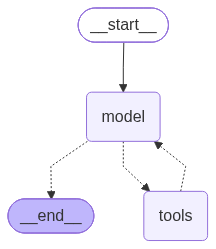

In [23]:
display(Image(react_agent.get_graph().draw_mermaid_png()))

## 11. Try it — a single-hop question
A question that only needs one knowledge base (LangGraph). This should result in a
single call to `langgraph_docs_tool` before the agent answers.


In [24]:
single_hop = [HumanMessage(content="What is a checkpointer used for in LangGraph?")]

react_agent.invoke({"messages": single_hop})

{'messages': [HumanMessage(content='What is a checkpointer used for in LangGraph?', additional_kwargs={}, response_metadata={}, id='eb52047a-6928-42cc-bee3-5fde002ac107'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What is a checkpointer used for in LangGraph?" Likely from LangGraph docs. Use search tool.', 'tool_calls': [{'id': 'fc_6a62b6dd-c4ad-448a-81fd-59ab79998cab', 'function': {'arguments': '{"query":"checkpointer LangGraph"}', 'name': 'langgraph_docs_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 401, 'total_tokens': 462, 'completion_time': 0.127822408, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.019430884, 'prompt_tokens_details': None, 'queue_time': 0.350055942, 'total_time': 0.147253292}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_02b0d31eca', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_

## 12. Try it — a multi-hop question
This question genuinely needs both knowledge bases: LangGraph's graph API and
LangChain's tool-calling agents. Watch the returned `messages` list — you should see
**two** separate `ToolMessage`s (one per tool) before the final `AIMessage`, showing the
agent chaining retrievals on its own rather than stopping after the first one.


In [25]:
multi_hop = [HumanMessage(content=(
    "I'm deciding between LangGraph's graph API and LangChain's built-in agents for a "
    "new project. Using details from both docs, explain how a LangGraph StateGraph "
    "differs from a LangChain agent's tool-calling loop."
))]

result = react_agent.invoke({"messages": multi_hop})
result

{'messages': [HumanMessage(content="I'm deciding between LangGraph's graph API and LangChain's built-in agents for a new project. Using details from both docs, explain how a LangGraph StateGraph differs from a LangChain agent's tool-calling loop.", additional_kwargs={}, response_metadata={}, id='ca073b8c-bd02-4c43-ab82-eab300a18959'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compare LangGraph StateGraph vs LangChain agent's tool-calling loop. Need info from both docs. So we need to search LangGraph docs for StateGraph, and LangChain docs for agent tool-calling loop. Use two searches each maybe.\n\nFirst search LangGraph docs.", 'tool_calls': [{'id': 'fc_0ad490df-9561-424c-8ad1-9f912791a542', 'function': {'arguments': '{"query":"StateGraph"}', 'name': 'langgraph_docs_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 435, 'total_tokens': 525, 'completion_time': 0.188436776, 'completion_tokens_det

## 13. Inspect which tools actually got called
A quick pass over the returned messages to print each tool call the agent made and in
what order — useful for confirming multi-hop behavior without reading the full
transcript above.


In [26]:
for m in result["messages"]:
    tool_calls = getattr(m, "tool_calls", None)
    if tool_calls:
        for tc in tool_calls:
            print(f"Called tool: {tc['name']}  |  args: {tc['args']}")

Called tool: langgraph_docs_tool  |  args: {'query': 'StateGraph'}
Called tool: langchain_docs_tool  |  args: {'query': 'agent tool calling loop'}
Called tool: langgraph_docs_tool  |  args: {'query': 'StateGraph overview'}
Called tool: langchain_docs_tool  |  args: {'query': 'AgentExecutor tool calling loop'}
Called tool: langgraph_docs_tool  |  args: {'query': 'StateGraph definition'}
